## QC (continued) for VUW_PISM
Control runs for VUW_PISM1 and VUW_PISM1_s* have spikes every ~10 yrs in the control runs, for floating area over time, draft depth over time, and potentially other variables. Why is it the case? And is it important?

This only occurs for the VUW_PISM1 and _not_ VUW_PISM2 experiments. According to the manuscript preprint (Seroussi, Earth's Future, Appendix B), the difference between both experiments is: _"The two main runs, PISM1 and PISM2, were run without and with subgrid basal melt at the grounding line, respectively."_ Presumably that explains the spikes.

Summarizing the notebook below:
- spikes are only ~5% of total ice area, so maybe not significant
- no visual differences in floating mask during spike
- potentially relevant model outputs of calving and grounding line flux are missing
- probably related to basal melt parametrization at GL -> _artificially adding floating ice at certain intervals?_

In [1]:
import numpy as np
import xarray as xr
from matplotlib import pylab as plt
import pandas as pd

/home/mkjs0/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
basepath = '/home/mkjs0/mount/gadi/'
model = 'VUW_PISM1'
model_base = 'AIS_' + model # this is the text (stays the same) in the actual data file that incorporates the model and usually AIS
model_reso = '8'
pth_scalar_values = '/home/mkjs0/research/python/hackathon/ComputedScalars'

In [3]:
# File paths for CTRL run
exp1='ctrlAE_'+model_reso
exp2='ctrlAE'

mask_floating = 'sftflf_' + model_base + '_' + exp2 + '.nc'
draft = 'base_' + model_base + '_' + exp2 + '.nc'
bmboutput = 'libmassbffl_' + model_base + '_' + exp2 + '.nc'
smb = 'acabf_' + model_base + '_' + exp2 + '.nc'
bed = 'topg_' + model_base + '_' + exp2 + '.nc'
thk = 'lithk_' + model_base + '_' + exp2 + '.nc'

In [5]:
d =xr.open_dataset(basepath+model +'/'+exp1+'/'+mask_floating)

/home/mkjs0/.local/lib/python3.10/site-packages/xarray/coding/times.py:170: SerializationWarning: Ambiguous reference date string: 1-1-1. The first value is assumed to be the year hence will be padded with zeros to remove the ambiguity (the padded reference date string is: 0001-1-1). To remove this message, remove the ambiguity by padding your reference date strings with zeros.
  warnings.warn(warning_msg, SerializationWarning)


In [6]:
mask = d

### result from prev. notebook -- spikes in floating area

Text(0.5, 0, 'Runtime - years')

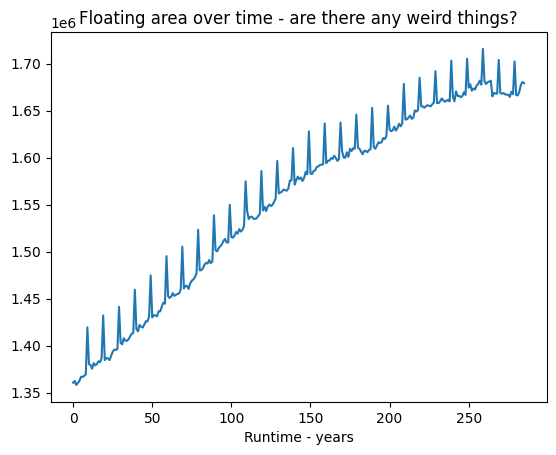

In [7]:
ts = np.nansum(mask.sftflf, axis=(1,2) )*8*8 

plt.figure()
plt.title('Floating area over time - are there any weird things?')
plt.plot(ts)
plt.xlabel('Runtime - years')

### Check values of spikes and their relative magnitude. looks significant in plot above but is less than 5% of total area

In [17]:
ts
print(ts[8], ts[9], ts[10]) # first spike
print((ts[9] - ts[8]) / ts[8]) # relative change of spike wrt total value

1369408 1419392 1380224
0.03650044398747488


### Plot floating mask before, during, and after first spike (no visual differences)

[None, None, None]

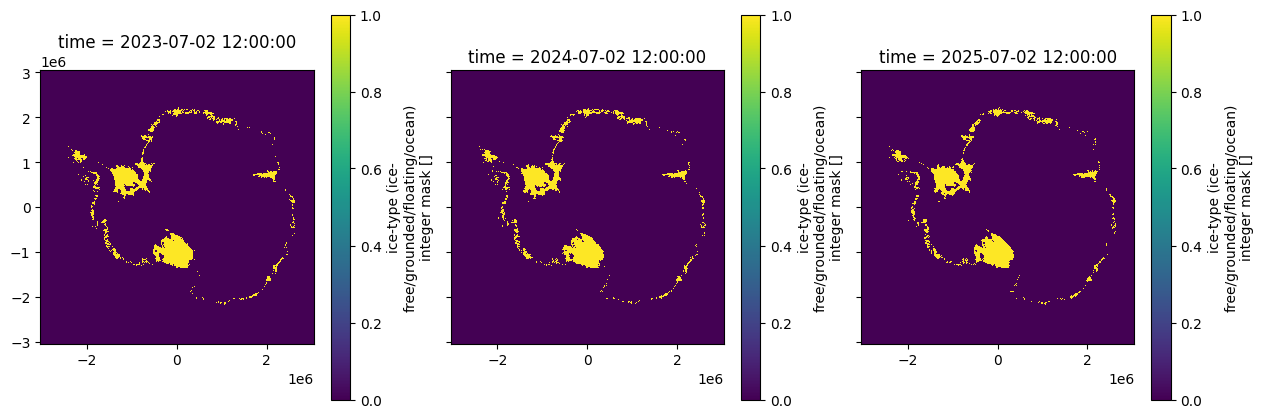

In [25]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
mask.sftflf[8, :, :].plot(ax = axs[0])
mask.sftflf[9, :, :].plot(ax = axs[1])
mask.sftflf[10, :, :].plot(ax = axs[2])
# diff = mask.sftflf[-1,:,:] - mask.sftflf[0,:,:]
# diff.plot(ax = ax4)
# ax4.set_title('Difference 2015-2300')

[ax.set_ylabel('') for ax in axs]
[ax.set_xlabel('') for ax in axs]

[ax.set_aspect('equal') for ax in axs]

### Anything related in calving or grounding line flux? Both files missing... (also missing in PISM2 experiments)

In [28]:
lifmassbf = 'lifmassbf_' + model_base + '_' + exp2 + '.nc' 

calv = xr.open_dataset(basepath+model +'/'+exp1 +'/'+lifmassbf)


FileNotFoundError: [Errno 2] No such file or directory: '/home/mkjs0/mount/gadi/VUW_PISM1/ctrlAE_8/lifmassbf_AIS_VUW_PISM1_ctrlAE.nc'

In [29]:
ligroundf = 'ligroundf_' + model_base + '_' + exp2 + '.nc' 
gl_flux = xr.open_dataset(basepath+model +'/'+exp1 +'/'+ligroundf)

FileNotFoundError: [Errno 2] No such file or directory: '/home/mkjs0/mount/gadi/VUW_PISM1/ctrlAE_8/ligroundf_AIS_VUW_PISM1_ctrlAE.nc'